In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('/Users/user/Documents/spotify_intelligence_copilot/data/spotify-tracks-dataset.csv', index_col=0)
df = df.drop(columns=['Unnamed: 0'], errors='ignore')

print(f"Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nGenres: {df['track_genre'].nunique()}")
print(f"Artists: {df['artists'].nunique()}")
print(f"Tracks: {df['track_name'].nunique()}")
df.head()

Shape: (114000, 20)

Columns: ['track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']

Genres: 114
Artists: 31437
Tracks: 73608


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [4]:
print("Missing values:")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")
print(f"\nPopularity range: {df['popularity'].min()} - {df['popularity'].max()}")
print(f"Avg popularity: {df['popularity'].mean():.1f}")

Missing values:
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

Duplicate rows: 450

Popularity range: 0 - 100
Avg popularity: 33.2


In [5]:
genre_stats = df.groupby('track_genre').agg(
    avg_popularity=('popularity', 'mean'),
    track_count=('track_name', 'count'),
    avg_danceability=('danceability', 'mean'),
    avg_energy=('energy', 'mean'),
    avg_valence=('valence', 'mean')
).reset_index().sort_values('avg_popularity', ascending=False)

print("Top 15 genres by popularity:")
print(genre_stats.head(15).to_string(index=False))

Top 15 genres by popularity:
      track_genre  avg_popularity  track_count  avg_danceability  avg_energy  avg_valence
         pop-film          59.283         1000          0.597146    0.604562     0.529253
            k-pop          56.896          999          0.647732    0.675654     0.556915
            chill          53.651         1000          0.664346    0.426723     0.403770
              sad          52.379         1000          0.692378    0.462470     0.422050
           grunge          49.594         1000          0.457062    0.803290     0.400373
           indian          49.539         1000          0.592273    0.567121     0.463024
            anime          48.772         1000          0.537451    0.674108     0.434463
              emo          48.128         1000          0.599321    0.669967     0.441135
        sertanejo          47.866         1000          0.591647    0.710391     0.619325
              pop          47.576         1000          0.630441    0.6

In [6]:
artist_stats = df.groupby('artists').agg(
    avg_popularity=('popularity', 'mean'),
    track_count=('track_name', 'count'),
    avg_danceability=('danceability', 'mean'),
    avg_energy=('energy', 'mean')
).reset_index()

artist_stats = artist_stats[artist_stats['track_count'] >= 3]
top_artists = artist_stats.sort_values('avg_popularity', ascending=False).head(20)

print("Top 20 artists by popularity:")
print(top_artists[['artists','avg_popularity','track_count']].to_string(index=False))

Top 20 artists by popularity:
                        artists  avg_popularity  track_count
                  Manuel Turizo       98.000000            4
     Bad Bunny;Chencho Corleone       97.000000            4
        Bad Bunny;Bomba Estéreo       94.500000            4
                   Harry Styles       92.000000            3
                      Luar La L       90.500000            4
            Bad Bunny;Tony Dize       90.000000            3
       Bad Bunny;Rauw Alejandro       90.000000            3
                    Nicki Minaj       89.000000            3
   Lost Frequencies;Calum Scott       88.000000            3
    The Kid LAROI;Justin Bieber       87.500000            4
                 Olivia Rodrigo       87.400000            5
                      Bad Bunny       87.083333           48
    benny blanco;BTS;Snoop Dogg       87.000000            3
Tainy;Bad Bunny;Julieta Venegas       87.000000            3
               Bad Bunny;Jhayco       87.000000        

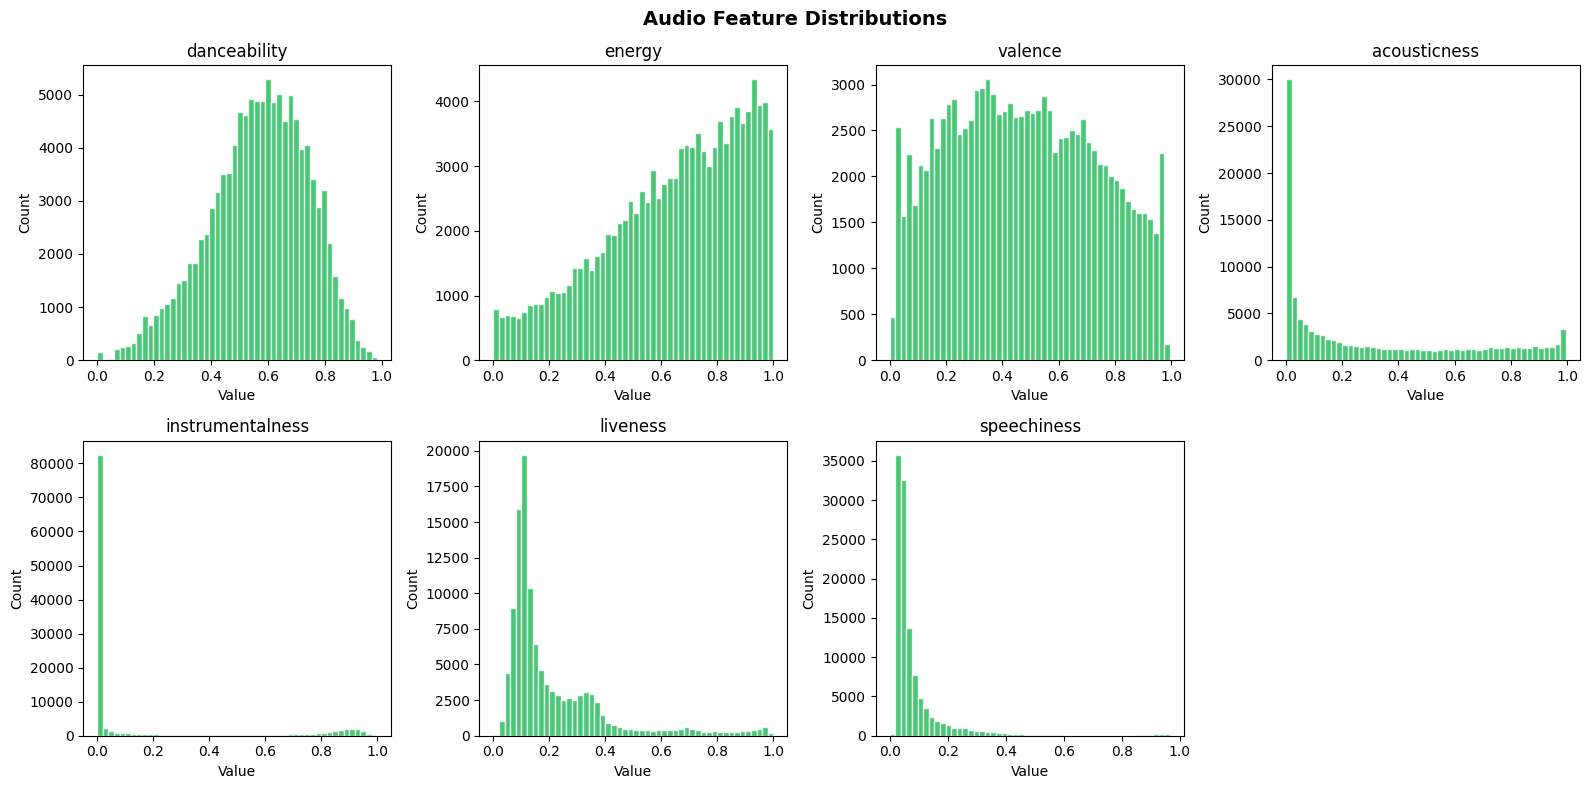

In [7]:
audio_features = ['danceability','energy','valence','acousticness',
                  'instrumentalness','liveness','speechiness']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Audio Feature Distributions', fontsize=14, fontweight='bold')

for ax, feature in zip(axes.flatten(), audio_features):
    ax.hist(df[feature], bins=50, color='#1DB954', edgecolor='white', alpha=0.8)
    ax.set_title(feature)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')

axes.flatten()[-1].set_visible(False)
plt.tight_layout()
plt.show()

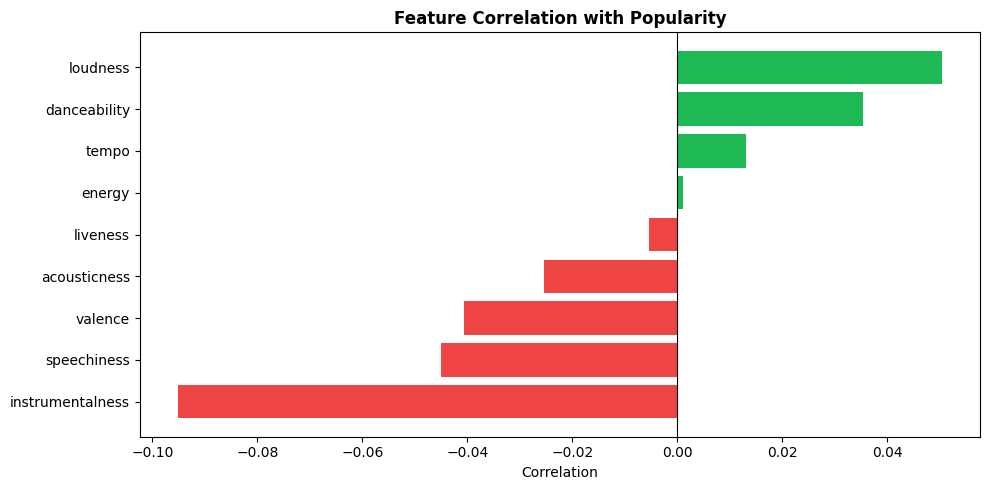


Correlations with popularity:
instrumentalness   -0.095
speechiness        -0.045
valence            -0.041
acousticness       -0.025
liveness           -0.005
energy              0.001
tempo               0.013
danceability        0.035
loudness            0.050
Name: popularity, dtype: float64


In [8]:
features = ['danceability','energy','valence','acousticness',
            'instrumentalness','liveness','speechiness','tempo','loudness']

correlations = df[features + ['popularity']].corr()['popularity'].drop('popularity').sort_values()

plt.figure(figsize=(10, 5))
colors = ['#EF4444' if v < 0 else '#1DB954' for v in correlations]
plt.barh(correlations.index, correlations.values, color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Correlation with Popularity', fontweight='bold')
plt.xlabel('Correlation')
plt.tight_layout()
plt.show()

print("\nCorrelations with popularity:")
print(correlations.round(3))